# dR/dq for a massive scalar mediator — 3-panel figure

Trimmed version of `ScatteringRate_NSiteLattice_longwavelength_massiveMediator.ipynb`,
containing only what `plot_massive_scalar_mediator` (3 panels) needs.

Run top to bottom. Section map:

0. Imports and plot style
1. Physics helpers (rate class, kinematics, halo, Debye-Waller)
2. N-site structure factors (load + 1st order + 2nd-and-higher)
3. dR/dq from the numerical structure factors
4. Analytic 1st-order pieces (full and long-wavelength)
5. The figure


## 0. Imports and plot style

In [1]:
import sys

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

In [2]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix', 
    'font.size': 17,
    'figure.dpi': 200            
})

## 1. Physics helpers

### 1.1 Rate calculator

In [3]:
class RateCalculations:
    def __init__(self, mass_DM, q_val, omega_list,omega_threshold,s_factor,cross_section):
        c = 2.998e5 #in km/s
        self.mass_DM = mass_DM
        self.mass_proton = 938.272e3 # keV
        self.density_DM = 0.3e6 # keV/cm^3, plus minus 0.1
        self.density_target = 1.307e30 # keV/cm^3 from silicon density of 2329.6 kg/m3
        self.v_esc = 500/c 
        self.v_earth = 240/c 
        self.v_disp = 220/c
        self.q_val = q_val
        self.omega_list = omega_list 
        self.s_factor = s_factor
        self.omega_threshold = omega_threshold # detector threshold. keV
        self.cross_section = cross_section # cm^2
        self.v_max = self.v_esc + self.v_earth 
        self.num_density = 2.15e25 # per kg
        # unit conversion, ref: https://physics.nist.gov/cuu/Constants/energy.html
        self.keV2InvS = 2.418e17 *2*np.pi # keV to 1/s
        self.year2sec = 86400. * 365.
        self.keV2InvYr = self.keV2InvS * self.year2sec
        self.keV2kg = 1.78e-33
        self.keV2InvCm = 8.065e6 * 2*np.pi

    def get_v_min(self, mass_DM, q,):
        return self.omega_list/ q + q / (2 * mass_DM)
    
    def _inverse_mean_sol1(self, v_min):
        '''
        Helper function used in get_inverse_mean_func
        '''
        ratio = self.v_esc/self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2*ratio*np.exp(-ratio**2)) # 1904.07915 eqn 108
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf((v_min+self.v_earth)/self.v_disp) 
                                                       - sp.special.erf((v_min-self.v_earth)/self.v_disp))
                        - 4 * self.v_earth * np.exp(-ratio**2))   
        return self.v_disp**2 * np.pi / (2*self.v_earth*norm_fac) * vel_integral 

    def _inverse_mean_sol2(self,v_min): 
        '''
        Helper function used in get_inverse_mean_func
        '''
        ratio = self.v_esc/self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2*ratio*np.exp(-ratio**2))
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf(ratio) 
                                                       - sp.special.erf((v_min-self.v_earth)/self.v_disp))
                        - 2 * (self.v_esc-v_min+self.v_earth) * np.exp(-ratio**2 ))   
        return self.v_disp**2 * np.pi / (2*self.v_earth*norm_fac) * vel_integral


    def get_inverse_mean_func(self,mass_DM, q,): # 1509.01598 appendix B
        '''
        returns: inverse mean function, 3d array with the same shape as v_min (num of DM mass, num of p, num of omega)
        '''
        v_min = self.get_v_min(mass_DM, q)
        return np.where(v_min>(self.v_esc+self.v_earth), 0., 
                        np.where(v_min<(self.v_esc-self.v_earth),
                                self._inverse_mean_sol1(v_min),
                                self._inverse_mean_sol2(v_min)))
    
    
    def _get_omega_mask(self,):
        omega_max = self.q_val * self.v_max - self.q_val**2 / (2 * self.mass_DM)
        return (self.omega_list > self.omega_threshold) & (self.omega_list < omega_max)

    
    def get_diff_rate_dRdq(self, ): # 2108.03239 eqn 11
        reducedMass = self.mass_DM * self.mass_proton/(self.mass_DM + self.mass_proton)
        constFactor = self.density_DM * self.cross_section / (4* np.pi * self.density_target * self.mass_DM * reducedMass**2)
        omega_mask = self._get_omega_mask()
        if np.sum(omega_mask)<2: 
            return 0.
        else:
            integrand = self.get_inverse_mean_func(self.mass_DM,self.q_val) * self.s_factor * self.q_val
            return 2*constFactor * sp.integrate.simpson(integrand[omega_mask], self.omega_list[omega_mask]) * self.keV2InvCm**2 * self.keV2InvYr / self.keV2kg # per kg-year-keV
    
    def get_v_min_nr(self):
        reducedMass = self.mass_DM * self.mass_proton*28/(self.mass_DM + self.mass_proton*28)
        return np.sqrt(28*self.mass_proton * self.omega_list / (2*reducedMass))
        
    def get_inverse_mean_func_nr(self,): # 1509.01598 appendix B
        '''
        returns: inverse mean function, 3d array with the same shape as v_min (num of DM mass, num of p, num of omega)
        '''
        v_min = self.get_v_min_nr()
        return np.where(v_min>(self.v_esc+self.v_earth), 0., 
                        np.where(v_min<(self.v_esc-self.v_earth),
                                self._inverse_mean_sol1(v_min),
                                self._inverse_mean_sol2(v_min)))

    def get_nr_diff_rate_dRdq(self):
        reducedMass = self.mass_DM * self.mass_proton*28/(self.mass_DM + self.mass_proton*28)
        return self.num_density * (self.density_DM / self.mass_DM) * (self.cross_section*(self.mass_proton*28)/(2*reducedMass**2)) * 28**2 * self.get_inverse_mean_func_nr()

### 1.2 Kinematic limits

$$q_\pm \equiv m_\chi v \left(1 \pm \sqrt{1 - \frac{2\omega_{th}}{m_\chi v^2}}\right),
\qquad \omega_+ \equiv q v - \frac{q^2}{2 m_\chi}$$

In [4]:
def get_q_lim(mass_DM, omega_threshold=10e-6):
    v_max = 0.00247 # in c
    q_min = mass_DM * v_max * (1 - np.sqrt(1-2*omega_threshold/(mass_DM * (v_max**2))))
    q_max = mass_DM * v_max * (1 + np.sqrt(1-2*omega_threshold/(mass_DM * (v_max**2))))
    return  q_min, q_max

def get_omega_lim(mass_DM, q,): 
    v_max = 0.00247 # in c
    return q * v_max - q**2 / (2 * mass_DM)

### 1.3 Impulse approximation (used for $q$ beyond the tabulated grid)

In [5]:
def get_impulse_approx(q, omega_list, omega_avg=30e-6, ):
    mass=26161e3 # sillicon, keV
    latticeConst= 2*np.pi/2.28 # si, keV^-3
    deltasq = q**2 * omega_avg/(2*mass)
    return 28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omega_list-(q**2/(2*mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)

### 1.4 Halo velocity integral, rate prefactor, Debye-Waller factor

In [6]:
C_KM_S = 2.998e5
V_ESC = 500 / C_KM_S
V_EARTH = 240 / C_KM_S
V_DISP = 220 / C_KM_S

def _get_shared_params():
    """Calculates normalization factors used in both solutions."""
    ratio = V_ESC / V_DISP
    norm_fac = (V_DISP**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2 * ratio * np.exp(-ratio**2))
    return ratio, norm_fac

def inverse_mean_sol1(v_min):
    ratio, norm_fac = _get_shared_params()
    
    vel_integral = (np.sqrt(np.pi) * V_DISP * (sp.special.erf((v_min + V_EARTH) / V_DISP) 
                                               - sp.special.erf((v_min - V_EARTH) / V_DISP))
                    - 4 * V_EARTH * np.exp(-ratio**2))   
    
    return V_DISP**2 * np.pi / (2 * V_EARTH * norm_fac) * vel_integral 

def inverse_mean_sol2(v_min): 
    ratio, norm_fac = _get_shared_params()
    
    vel_integral = (np.sqrt(np.pi) * V_DISP * (sp.special.erf(ratio) 
                                               - sp.special.erf((v_min - V_EARTH) / V_DISP))
                    - 2 * (V_ESC - v_min + V_EARTH) * np.exp(-ratio**2))   
    
    return V_DISP**2 * np.pi / (2 * V_EARTH * norm_fac) * vel_integral

def get_inverse_mean_func(v_min): 
    """
    Stand-alone calculation for the DM velocity integral.
    Accepts v_min as a float or numpy array.
    """
    # Logic gates based on Earth's velocity and Galactic escape velocity
    cond_zero = v_min > (V_ESC + V_EARTH)
    cond_sol1 = v_min < (V_ESC - V_EARTH)
    
    return np.where(cond_zero, 0., 
                    np.where(cond_sol1,
                             inverse_mean_sol1(v_min),
                             inverse_mean_sol2(v_min)))

def get_const_factor_value(mass_DM, cross_section=1e-40):
    # Constants from your code
    m_p = 938.272e3        # keV
    rho_DM = 0.3e6         # keV/cm^3
    rho_T = 1.307e30       # keV/cm^3
    
    # Unit conversions
    keV2InvS = 2.418e17 *2*np.pi 
    year2sec = 86400. * 365.
    keV2InvYr = keV2InvS * year2sec
    keV2kg = 1.78e-33
    keV2InvCm = 8.065e6 * 2*np.pi
    
    conversion_combined = (keV2InvCm**2 * keV2InvYr) / keV2kg
    
    reduced_mass_inv_sq = ((mass_DM + m_p)**2) / (mass_DM**2 * m_p**2)
    
    static_prefactor = (rho_DM * cross_section ) / (4 * np.pi * rho_T)
    
    return 2*  (static_prefactor / mass_DM) * reduced_mass_inv_sq * conversion_combined

def get_DebyeWallerConst(q_value, nLattice=100, mass=26161e3, omegaNaught=10e-6, energyThreshold=1e-6):
    """
    Calculates the Debye-Waller constant W(q) for a given momentum transfer q.
    
    Parameters:
    - q_value: Momentum transfer (keV^-1)
    - nLattice: Number of lattice points (default: 100)
    - mass: Mass of the nucleus in keV (default: 26161e3 for Silicon)
    - omegaNaught: Base frequency in keV (default: 10e-6)
    - energyThreshold: Minimum energy filter in keV (default: 1e-6)
    
    Returns:
    - W(q): The Debye-Waller constant (dimensionless)
    """
    # 1. Generate the frequencies for the given number of lattice points
    nu = np.arange(1, nLattice)
    omegaList = 2 * omegaNaught * np.sin(np.pi * nu / nLattice)
    
    # 2. Filter out frequencies below the energy threshold
    omegaList = omegaList[omegaList >= energyThreshold]
    
    # 3. Compute W(q)
    sum_inv_omega = np.sum(1 / omegaList)
    W_q = (q_value**2) / (4 * mass * nLattice) * sum_inv_omega
    
    return W_q

## 2. N-site structure factors

`nSiteSFactor_lwa_drdq.npz` must be in the working directory, and
`StructureFactor1D.py` on `sys.path` (edit the path below for your machine).

In [7]:
nSiteData = np.load("nSiteSFactor_lwa_drdq.npz")
s_factor_nSite = nSiteData["s_tot"]
s_factor_nSite_incoh = nSiteData["s_diag"]
s_factor_nSite_incoh_lwa = nSiteData["s_lwa"]
q_list_nSite = nSiteData["qlist"]
omega_list_nSite = nSiteData["omegalist"]

In [8]:
sys.path.append(r"C:/Users/xylin/Documents/Researches/multiphonon-direct-detection/StructureFactor1D.py")
from StructureFactor1D import StructureFactor1D
def calc_first_order_s_factor(q_value, omegalength, nLattice, max_omega): 
    # Initialize the calculator
    sFacCalc = StructureFactor1D(nLattice=nLattice, q_value=q_value, couplingConst=28)
    xlist, delta_omega = np.linspace(0, max_omega, omegalength, retstep=True) 
    
    # Setup and compute first order (init_recursion computes the 1st order)
    sFacCalc.setup_DoS(max_omega, nBins=1000)
    sFacCalc.init_recursion(print_message=False)
    
    # Fetch the 1st-order binned data
    s_diag = sFacCalc.get_binned_s_diag(xlist, delta_omega)
    s_offdiag = sFacCalc.get_binned_s_offdiag(xlist, delta_omega)
    

    # The total structure factor for 1st order is just the sum of diagonal and off-diagonal
    s_tot = s_diag + s_offdiag
    s_diag_tot = s_diag.copy()
    
    return s_diag_tot, s_tot


def calc_second_order_s_factor(q_value, omegalength, nLattice, max_omega): 
    # Initialize the calculator
    sFacCalc = StructureFactor1D(nLattice=nLattice, q_value=q_value, couplingConst=28)
    xlist, delta_omega = np.linspace(0, max_omega, omegalength, retstep=True) 
    
    # Setup DoS
    sFacCalc.setup_DoS(max_omega, nBins=1000)
    
    # Compute 1st order
    sFacCalc.init_recursion(print_message=False)
    
    # Compute 2nd order
    sFacCalc.update_s_factor(print_message=False)
    
    # Fetch the 2nd-order binned data
    s_diag = sFacCalc.get_binned_s_diag(xlist, delta_omega)
    s_offdiag = sFacCalc.get_binned_s_offdiag(xlist, delta_omega)
    
    # The total structure factor for the isolated 2nd order
    s_tot = s_diag + s_offdiag
    s_diag_tot = s_diag.copy()
    
    return s_diag_tot, s_tot


def calc_third_order_s_factor(q_value, omegalength, nLattice, max_omega): 
    # Initialize the calculator
    sFacCalc = StructureFactor1D(nLattice=nLattice, q_value=q_value, couplingConst=28)
    xlist, delta_omega = np.linspace(0, max_omega, omegalength, retstep=True) 
    
    # Setup DoS
    sFacCalc.setup_DoS(max_omega, nBins=1000)
    
    # Compute 1st order
    sFacCalc.init_recursion(print_message=False)
    
    # Compute 2nd order
    sFacCalc.update_s_factor(print_message=False)
    
    # Compute 3rd order
    sFacCalc.update_s_factor(print_message=False)
    
    # Fetch the 3rd-order binned data
    s_diag = sFacCalc.get_binned_s_diag(xlist, delta_omega)
    s_offdiag = sFacCalc.get_binned_s_offdiag(xlist, delta_omega)
    
    # The total structure factor for the isolated 3rd order
    s_tot = s_diag + s_offdiag
    s_diag_tot = s_diag.copy()
    
    return s_diag_tot, s_tot

### 2.1 First-order structure factor on the tabulated $q$ grid

In [9]:
omegalength = len(omega_list_nSite)
max_omega = 250 * 1e-6
nLattice = 100

# --- Grid Generation ---
omegalist = np.linspace(0, max_omega, omegalength) 
qscale = np.sqrt(2 * 26161e3 * 13.13e-6) 
qlist = q_list_nSite

# --- Initialize lists to store results ---
res_diag = []
res_tot = []
res_lwa = []

# --- Simple Sequential Loop Execution ---
for idx, q in enumerate(qlist):
    # Optional progress tracker (since 1000 iterations might take a moment)
    if idx % 100 == 0:
        print(f"Processing q-point {idx}...")
        
    # Call the 1st-order function
    s_diag_tot, s_tot = calc_first_order_s_factor(
        q_value=q, 
        omegalength=omegalength, 
        nLattice=nLattice, 
        max_omega=max_omega
    )
    
    # Append the 1D arrays to our results lists
    res_diag.append(s_diag_tot)
    res_tot.append(s_tot)
    
# --- Data Aggregation ---
finalresdiag_1st = np.array(res_diag)
finalres_1st = np.array(res_tot)

Processing q-point 0...
Processing q-point 100...
Processing q-point 200...
Processing q-point 300...
Processing q-point 400...
Processing q-point 500...
Processing q-point 600...
Processing q-point 700...
Processing q-point 800...
Processing q-point 900...
Processing q-point 1000...
Processing q-point 1100...
Processing q-point 1200...
Processing q-point 1300...
Processing q-point 1400...


### 2.2 Second-and-higher order

Subtract the 1st order from the total, so the analytic 1st-order results of
section 4 can be added back on top.

In [10]:
s_factor_nSite_2ndandhigher = s_factor_nSite - finalres_1st
s_factor_nSite_2ndandhigher_incoh = s_factor_nSite_incoh - finalresdiag_1st

## 3. dR/dq from the numerical structure factors

In [11]:
dmmasslist_4plot = np.array([100,1e3, 10e3, 100e3, 1e6])

In [12]:
def calculate_diff_rates(s_factor_nSite, s_factor_nSite_incoh, q_list_nSite, omega_list_nSite, 
                         dmmasslist=None, omega_threshold=1e-6, cross_section=1e-40, omega_avg=13.13e-6):
    """
    Calculates the differential rates (dR/dq) for dark matter scattering.
    
    Parameters:
    - s_factor_nSite: Structure factor array.
    - s_factor_nSite_incoh: Incoherent structure factor array.
    - q_list_nSite: List of momentum transfers.
    - omega_list_nSite: List of energy transfers.
    - dmmasslist: Array of dark matter masses (defaults to standard plotting masses if None).
    - omega_threshold: Minimum energy threshold.
    - cross_section: DM-nucleon cross section.
    - omega_avg: Average energy for the impulse approximation.
    
    Returns:
    - dRdq_result_4plot: List of arrays containing the coherent differential rates.
    - dRdq_result_incoh_4plot: List of arrays containing the incoherent differential rates.
    - qlist_4plot: List of q arrays corresponding to the rates (needed for plotting/integration).
    """
    
    if dmmasslist is None:
        dmmasslist = np.array([100, 1e3, 10e3, 100e3, 1e6]) # 10^2 ~ 10^6 keV

    dRdq_result_4plot = []
    dRdq_result_incoh_4plot = []
    qlist_4plot = []
    
    for ind_m, dmmass in enumerate(dmmasslist):    
        if ind_m % 10 == 0: 
            print(f'processing {ind_m}...')
            
        q_min, q_max = get_q_lim(dmmass, omega_threshold)
        
        if q_max < q_list_nSite[-1]:
            qlist = q_list_nSite
            dRdq_result = np.empty(len(q_list_nSite))
            dRdq_result_incoh = np.empty(len(q_list_nSite))
            
            for ind_q, q in enumerate(qlist): 
                # Coherent
                rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, s_factor_nSite[ind_q], cross_section)
                dRdq_result[ind_q] = rateCal.get_diff_rate_dRdq()
                
                # Incoherent
                rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, s_factor_nSite_incoh[ind_q], cross_section)
                dRdq_result_incoh[ind_q] = rateCal.get_diff_rate_dRdq()
                
        else: 
            omega_length = 4000
            q_length = 200
            qlist = np.concatenate((q_list_nSite, np.linspace(q_list_nSite[-1], q_max, q_length+1)[1:]))
            
            dRdq_result = np.empty(q_length + len(q_list_nSite))
            dRdq_result_incoh = np.empty(q_length + len(q_list_nSite))
            
            for ind_q, q in enumerate(q_list_nSite): 
                # Coherent
                rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, s_factor_nSite[ind_q], cross_section)
                dRdq_result[ind_q] = rateCal.get_diff_rate_dRdq()
                
                # Incoherent
                rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, s_factor_nSite_incoh[ind_q], cross_section)
                dRdq_result_incoh[ind_q] = rateCal.get_diff_rate_dRdq()
                
            for ind_q, q in enumerate(qlist[len(q_list_nSite):]): 
                omega_max = get_omega_lim(dmmass, q)
                omegalist = np.linspace(omega_threshold, omega_max, omega_length)
                s_factor_ia = get_impulse_approx(q, omegalist, omega_avg=omega_avg)
                
                # Impulse Approximation (applied to both)
                rateCal = RateCalculations(dmmass, q, omegalist, omega_threshold, s_factor_ia, cross_section)
                dRdq_result[ind_q + len(q_list_nSite)] = rateCal.get_diff_rate_dRdq()
                dRdq_result_incoh[ind_q + len(q_list_nSite)] = rateCal.get_diff_rate_dRdq()

        dRdq_result_4plot.append(dRdq_result)
        dRdq_result_incoh_4plot.append(dRdq_result_incoh)
        qlist_4plot.append(qlist)

    return dRdq_result_4plot, dRdq_result_incoh_4plot, qlist_4plot

### 3.1 Full and incoherent

In [13]:
dRdq_result_4plot, dRdq_result_incoh_4plot, qlist_4plot = calculate_diff_rates(s_factor_nSite, s_factor_nSite_incoh, q_list_nSite, omega_list_nSite, dmmasslist = np.array([100, 1e3, 10e3, 100e3, 1e6]))

processing 0...


### 3.2 Second-and-higher order only

In [14]:
dRdq_result_2ndandhigher_4plot, dRdq_result_2ndandhigher_incoh_4plot, qlist_4plot = calculate_diff_rates(s_factor_nSite_2ndandhigher, s_factor_nSite_2ndandhigher_incoh, q_list_nSite, omega_list_nSite, dmmasslist = np.array([100, 1e3, 10e3, 100e3, 1e6]))

processing 0...


## 4. Analytic 1st-order pieces

### 4.1 Full analytic 1st order &rarr; `drdq_result_halfanalytic_4plot`

In [15]:
def calculate_drdq_analytic(dmmasslist_4plot, qlist_4plot):
    """
    Calculates the analytic dR/dq result for a list of dark matter masses and q-lists.
    Requires external helper functions (get_DebyeWallerConst, get_inverse_mean_func, 
    get_const_factor_value) and StructureFactor1D class to be defined in the global scope.
    """
    # 1. Constants and initializations that don't depend on mchi or qlist
    a = 2 * np.pi / 2.28
    nLattice = 100
    
    # Initialize the structure factor calculator once
    sFacCalc = StructureFactor1D(nLattice=nLattice, q_value=70, couplingConst=28)

    # Calculate nu and omega_nu once outside the loop to save computation time
    nu = np.asarray(sFacCalc.nuList.flatten())[np.newaxis, :]     
    omega_nu = np.asarray(sFacCalc.omegaList)[np.newaxis, :]

    # List to store the results for each mass/qlist pair
    drdq_result_analytic_1st_4plot = []

    # 2. Loop through the paired masses and q-lists
    for mchi, qlist in zip(dmmasslist_4plot, qlist_4plot):
        
        # Kinematic calculations dependent on the current mchi and qlist
        omglst = (20e-6) * np.sin(qlist * 2.756 / 2)
        vmin = omglst / qlist + qlist / (2 * mchi)
        
        dwfactor = get_DebyeWallerConst(qlist)
        q = np.asarray(qlist)[:, np.newaxis]       
        
        # Calculate structure terms
        argument = q * a - (2 * np.pi * nu) / nLattice
        numerator = 1 - np.cos(nLattice * argument)
        denominator = 1 - np.cos(argument)
        
        bracket_term = (1 / nLattice) * (numerator / denominator)
        terms = bracket_term / omega_nu

        # Assemble final rate calculation for this iteration
        drdq_result = (
            qlist 
            * get_inverse_mean_func(vmin) 
            * get_const_factor_value(mchi) 
            * 2 * np.pi * 28**2 / ((2.756**3) / 4 * 100) 
            * np.exp(-2 * dwfactor) 
            * qlist**2 / (2 * 26161e3) 
            * np.sum(terms, axis=1)
        )
        
        # Store result
        drdq_result_analytic_1st_4plot.append(drdq_result)

    return drdq_result_analytic_1st_4plot

In [16]:
drdq_result_analytic_1st_4plot = calculate_drdq_analytic(dmmasslist_4plot, qlist_4plot)

In [17]:
drdq_result_halfanalytic_4plot = []
for i in range(len(dmmasslist_4plot)):
    drdq_result_halfanalytic_4plot.append(dRdq_result_2ndandhigher_incoh_4plot[i]+drdq_result_analytic_1st_4plot[i])

### 4.2 Long-wavelength analytic 1st order

In [18]:
def calculate_drdq_lwa_analytic_padded(dmmasslist_4plot, qlist_4plot):
    """
    Calculates the analytic dR/dq LWA approximation.
    Filters out points where omglst <= 1e-6, but returns an array of the same
    shape as the input qlist, with 0s filling the gaps.
    """
    drdq_lwa_analytic_4plot = []

    for mchi, qlist in zip(dmmasslist_4plot, qlist_4plot):
        
        omglst = (20e-6) * np.abs(np.sin(qlist * 2.756 / 2))
        valid_mask = omglst > 1e-6

        # 1. Initialize an array of zeros identical in size to the original qlist
        drdq_lwa_full = np.zeros_like(qlist)

        # 2. Extract valid elements for computation
        qlist_valid = qlist[valid_mask]
        omglst_valid = omglst[valid_mask]

        # 3. Perform calculations only on valid elements
        vmin = omglst_valid / qlist_valid + qlist_valid / (2 * mchi)
        dwfactor = get_DebyeWallerConst(qlist_valid)

        drdq_lwa_calc = (
            qlist_valid 
            * get_inverse_mean_func(vmin) 
            * qlist_valid**2 / (2 * 26161e3 * omglst_valid) 
            * 2 * np.pi * 28**2 / ((2.756**3) / 4) 
            * get_const_factor_value(mchi) 
            * np.exp(-2 * dwfactor)
        )

        # 4. Insert the calculated values back into the full-sized array where the mask is True
        drdq_lwa_full[valid_mask] = drdq_lwa_calc
        
        # Store the padded result
        drdq_lwa_analytic_4plot.append(drdq_lwa_full)

    return drdq_lwa_analytic_4plot

In [19]:
drdq_lwa_analytic_4plot = calculate_drdq_lwa_analytic_padded(dmmasslist_4plot, qlist_4plot)

`drdq_result_lwa_allqanalytic_4plot` — LW everywhere;
`drdq_result_lwa_qbzanalytic_4plot` — LW only below $q_{BZ}$, incoherent above.

In [20]:
drdq_result_lwa_allqanalytic_4plot = []
for i in range(len(dmmasslist_4plot)):
    drdq_result_lwa_allqanalytic_4plot.append(drdq_lwa_analytic_4plot[i]+dRdq_result_2ndandhigher_4plot[i])

In [21]:
drdq_result_lwa_qbzanalytic_4plot = []
for i in range(len(dmmasslist_4plot)):
    drdq_result_lwa_qbzanalytic_4plot.append(np.where(qlist_4plot[i]<1.14, drdq_lwa_analytic_4plot[i], dRdq_result_incoh_4plot[i]-dRdq_result_2ndandhigher_incoh_4plot[i])+dRdq_result_2ndandhigher_incoh_4plot[i])

## 5. Figure

In [22]:
qbz = 1.14
qscale = np.sqrt(2*26161e3*13.13e-6)
qia = 2*qscale

In [23]:
def plot_massive_scalar_mediator(qlist_4plot, dmmasslist_4plot, dRdq_result_4plot,
                                 dRdq_result_incoh_4plot,
                                 dRdq_result_incoh_lwa_qbz_4plot,
                                 n_masses=4):
    """
    Plots the dark matter scattering structure factors.
    """
    # Define 4 distinct colors for the 4 different masses
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

    # Create a figure with 3 subplots in one row. 'sharey=True' keeps the y-axis the same for all.
    fig, axes = plt.subplots(1, 3, figsize=(13, 6), sharey=True)

    # Set common configurations for all subplots
    titles = ['Full structure factor', 'Incoherent approximation', 'LW + Inc approximation']

    for j in range(3):
        axes[j].set_title(titles[j])
        axes[j].set_xscale('log')
        axes[j].xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=(1, 2, 3, 4, 5, 6, 7, 8, 9), numticks=100))
        axes[j].xaxis.set_minor_formatter(ticker.NullFormatter())
        axes[j].xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
        axes[j].set_yscale('log')
        axes[j].set_ylim(1e-6, 1e5)
        axes[j].set_xlim(0.055, 1e3)
        axes[j].set_xlabel('$q$ [keV]')

    # Only set the y-label on the leftmost plot
    axes[0].set_ylabel('$dR/dq$ [kg-yr-keV]$^{-1}$')
    axes[0].axvline(qia, color='gray', linestyle=':')
    axes[0].axvline(qbz, color='gray', linestyle=':')
    axes[0].text(qia*1.2, 2000, "$2\sqrt{2m\\bar\omega}$", color='gray', fontsize=14)
    axes[0].text(qbz*.35, 2400, r"$q_{BZ}$", color='gray', fontsize=14)
    
    # Plot the lines on their respective subplots
    for i in range(n_masses):
        c = colors[i] 
        
        # Column 1: Full
        axes[0].plot(qlist_4plot[i], dRdq_result_4plot[i], color=c, linestyle='-', lw=1.)
        
        # Column 2: Incoherent approximation (shifted from Column 3)
        axes[1].plot(qlist_4plot[i], dRdq_result_4plot[i], color=c, linestyle='--', lw=1., alpha=0.5)
        axes[1].plot(qlist_4plot[i], dRdq_result_incoh_4plot[i], color=c, linestyle='-', lw=1.)
        
        # Column 3: LW (q < q_bz) (shifted from Column 4)
        axes[2].plot(qlist_4plot[i], dRdq_result_4plot[i], color=c, linestyle='--', lw=1., alpha=0.5)
        axes[2].plot(qlist_4plot[i], dRdq_result_incoh_lwa_qbz_4plot[i], color=c, linestyle='-', lw=1.)
        
    # --- Creating the Style Legend ---
    # Placed in the 2nd column (axes[1]) to explain the dashed vs solid lines for columns 2-3
    style_handles = [
        Line2D([0], [0], color='black', linestyle='-', lw=1., label='Approximation'),
        Line2D([0], [0], color='black', linestyle='--', lw=1., alpha=0.5, label='Full (reference)')
    ]
    axes[1].legend(handles=style_handles, loc='best')
    
    # --- Creating the Mass Legend ---
    mass_handles = []
    for i in range(n_masses):
        mass_label = f'$m_\\chi$ = {dmmasslist_4plot[i]/1e3:.1f} MeV'
        mass_handles.append(Line2D([0], [0], color=colors[i], lw=2, label=mass_label))

    # Place the mass legend centered below the figure
    fig.legend(handles=mass_handles, title="Masses",
               loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=n_masses)

    # Overall figure title
    fig.suptitle("Massive Scalar Mediator", fontsize=24, y=.93)

    # Adjust layout so the titles and legend aren't clipped
    plt.tight_layout()
    # Adding 'bottom=0.32' gives the plots room so they don't overlap the bottom legend
    plt.subplots_adjust(wspace=0.07, bottom=0.32) 
    plt.show()
    
    # Return figure and axes objects in case you need to save or modify them later
    return fig, axes

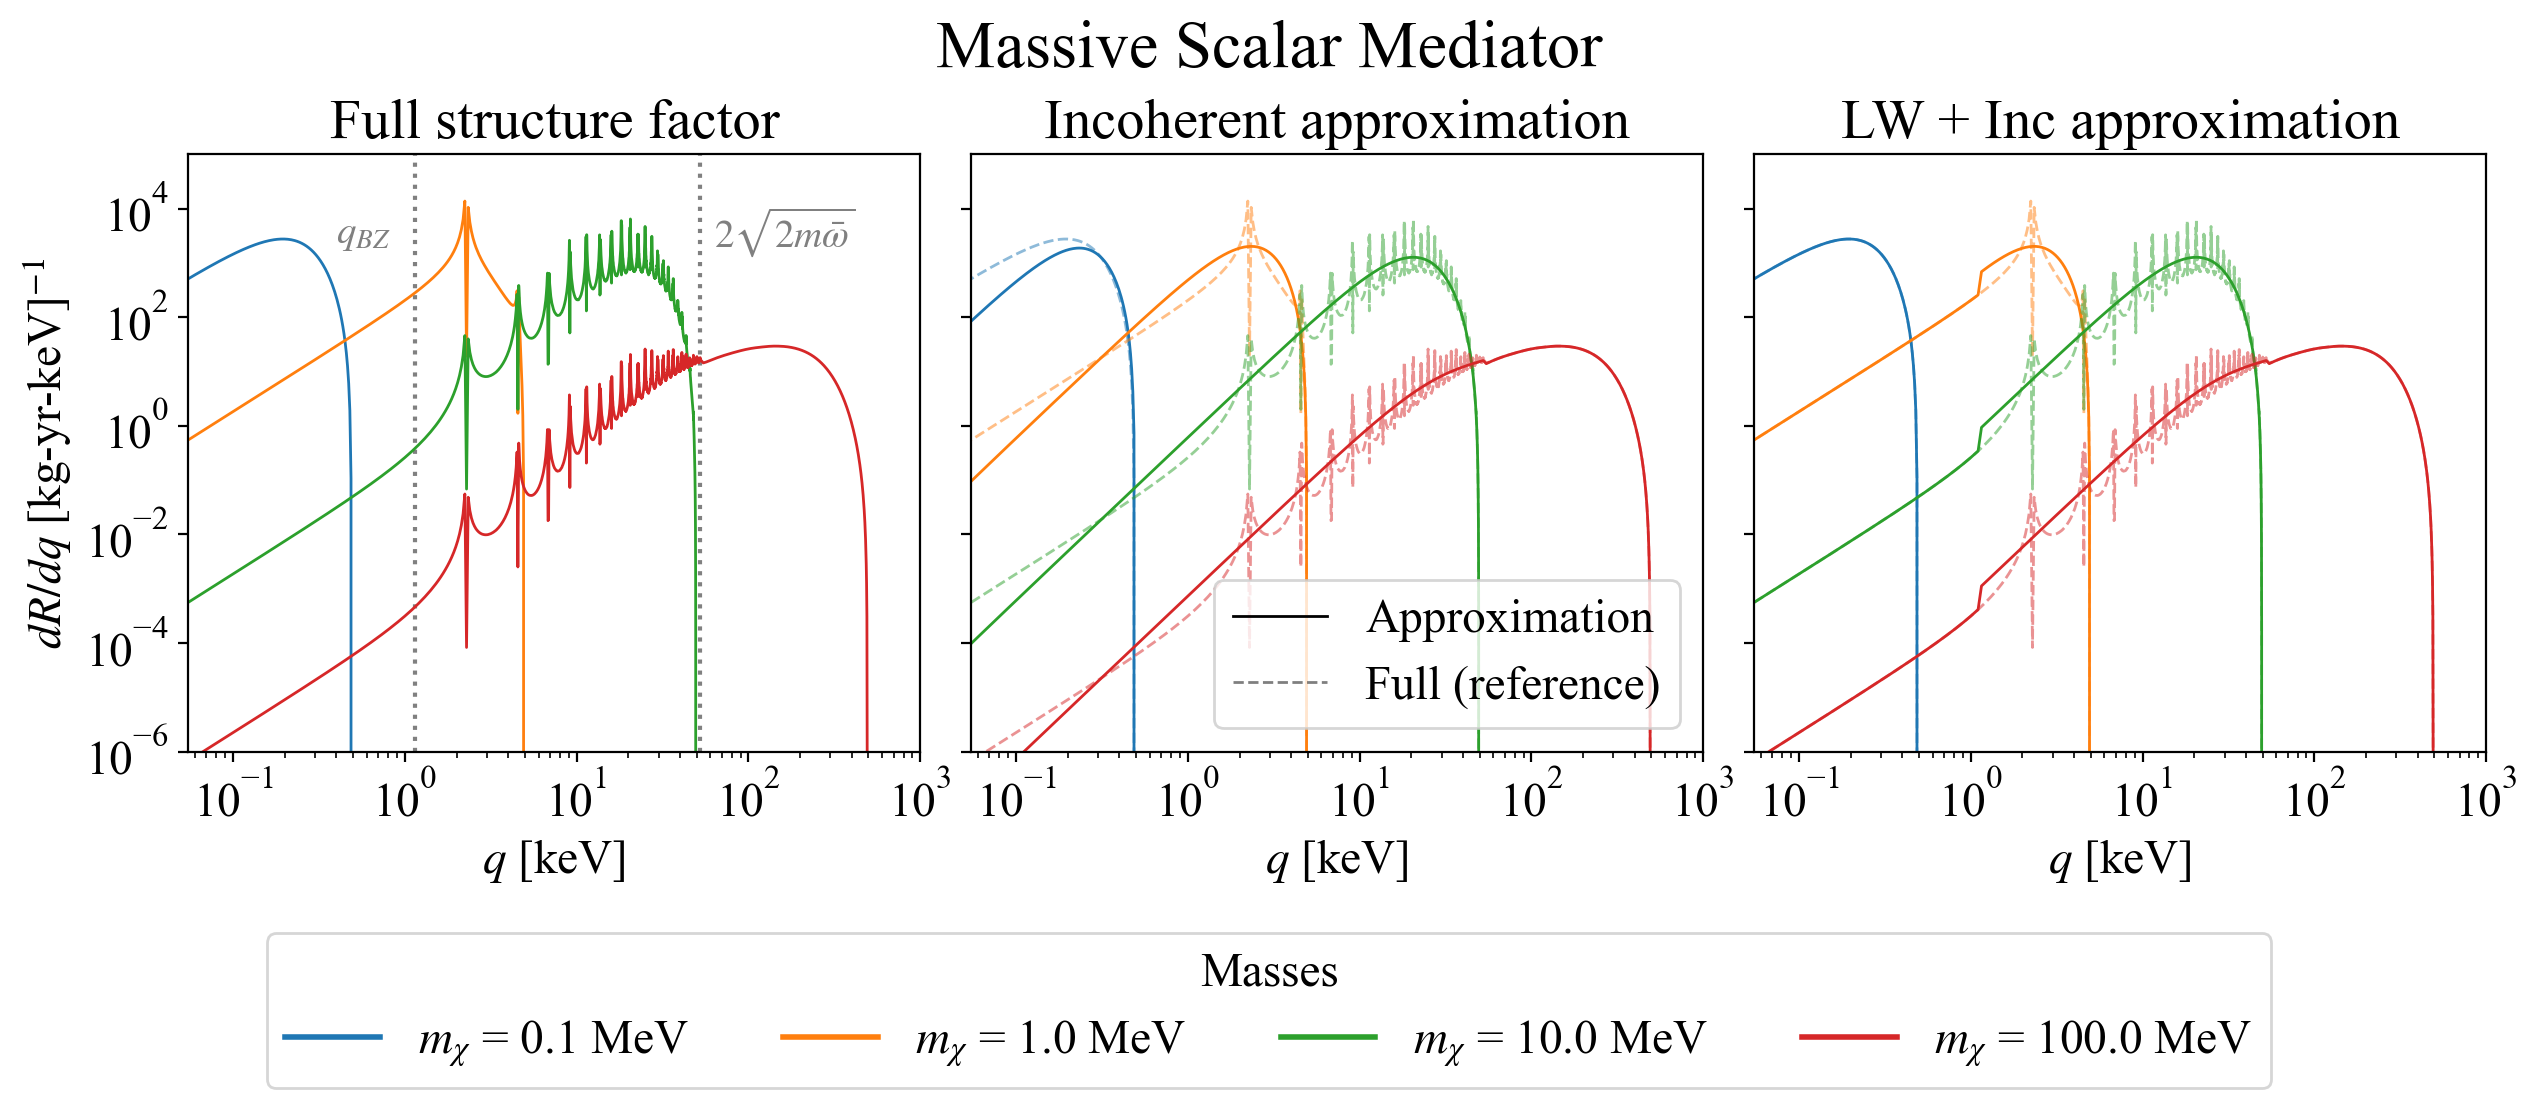

In [24]:
fig, axes = plot_massive_scalar_mediator(
    qlist_4plot,
    dmmasslist_4plot,
    dRdq_result_4plot=drdq_result_lwa_allqanalytic_4plot,   # panel 1: "Full structure factor"
    dRdq_result_incoh_4plot=dRdq_result_incoh_4plot,        # panel 2
    dRdq_result_incoh_lwa_qbz_4plot=drdq_result_lwa_qbzanalytic_4plot,  # panel 3
)